In [8]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

theta = 0.0
tau = 1.0 
sigma = 1.0 / np.sqrt(tau)  # стандартное отклонение

n = 30
m = 25

# Генерация выборок под H0
X = np.random.normal(loc=theta, scale=sigma, size=n)
Y = np.random.normal(loc=theta, scale=sigma, size=m)

In [9]:
# ------ Оценки параметров ------
# Оценки средних
mu_x = np.mean(X)
mu_y = np.mean(Y)

# Оценки дисперсий (несмещённые)
var_x = np.var(X, ddof=1)
var_y = np.var(Y, ddof=1)

# Объединённая оценка дисперсии (при H₀ предполагаем, что дисперсии равны)
pooled_var = ((n-1)*var_x + (m-1)*var_y) / (n + m - 2)
pooled_std = np.sqrt(pooled_var)

print(f"\nОценки по выборкам:")
print(f"X̄ = {mu_x:.4f}, s²_X = {var_x:.4f}")
print(f"Ȳ = {mu_y:.4f}, s²_Y = {var_y:.4f}")
print(f"Объединённая дисперсия: {pooled_var:.4f}")


Оценки по выборкам:
X̄ = -0.1881, s²_X = 0.8100
Ȳ = -0.1890, s²_Y = 0.9150
Объединённая дисперсия: 0.8576


In [10]:
# ------ Критерий отношения правдоподобия (LR) ------
# При H₁: разные средние, общая дисперсия
# При H₀: общее среднее, общая дисперсия

# Оценка общего среднего при H₀
mu_pooled = (n*mu_x + m*mu_y) / (n + m)

# Логарифмы правдоподобия
def log_likelihood(data, mu, var):
    """Логарифм правдоподобия для нормального распределения"""
    n = len(data)
    return -n/2 * np.log(2*np.pi*var) - np.sum((data - mu)**2) / (2*var)

# LL при H₁ (разные средние, общая дисперсия)
ll_h1 = log_likelihood(X, mu_x, pooled_var) + log_likelihood(Y, mu_y, pooled_var)

# LL при H₀ (общее среднее, общая дисперсия)
ll_h0 = log_likelihood(X, mu_pooled, pooled_var) + log_likelihood(Y, mu_pooled, pooled_var)

# Статистика отношения правдоподобия
lr_stat = 2 * (ll_h1 - ll_h0)
p_value_lr = 1 - stats.chi2.cdf(lr_stat, df=1)

print(f"\n--- Критерий отношения правдоподобия (LR) ---")
print(f"Статистика LR: {lr_stat:.4f}")
print(f"P-значение: {p_value_lr:.4f}")

alpha = 0.05
chi2_crit = stats.chi2.ppf(1 - alpha, df=1)
if lr_stat > chi2_crit:
    print(f"Отвергаем H₀ (p < {alpha}) → средние различаются")
else:
    print(f"Не отвергаем H₀ (p >= {alpha}) → нет оснований считать средние разными")


--- Критерий отношения правдоподобия (LR) ---
Статистика LR: 0.0000
P-значение: 0.9973
Не отвергаем H₀ (p >= 0.05) → нет оснований считать средние разными


In [11]:
# ------ Классический t-критерий Стьюдента (для сравнения) ------
t_stat, p_value_t = stats.ttest_ind(X, Y)
print(f"\n--- t-критерий Стьюдента (для проверки) ---")
print(f"t-статистика: {t_stat:.4f}")
print(f"P-значение: {p_value_t:.4f}")

# ------ Критерий Уилкоксона-Манна-Уитни (непараметрический) ------
u_stat, p_value_w = stats.mannwhitneyu(X, Y, alternative='two-sided')
print(f"\n--- Критерий Уилкоксона-Манна-Уитни ---")
print(f"U-статистика: {u_stat:.0f}")
print(f"P-значение: {p_value_w:.4f}")


--- t-критерий Стьюдента (для проверки) ---
t-статистика: 0.0033
P-значение: 0.9974

--- Критерий Уилкоксона-Манна-Уитни ---
U-статистика: 372
P-значение: 0.9663


/var/folders/q7/70k5z3797l7953_1tz5w6xcr0000gn/T/ipykernel_62020/1894056090.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X, Y], labels=['Выборка X', 'Выборка Y'])


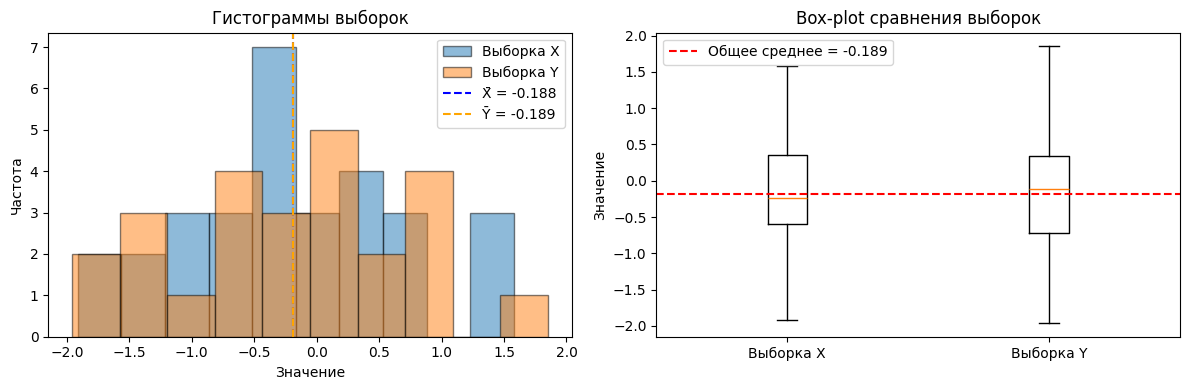

In [12]:
# ------ Визуализация ------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограммы
axes[0].hist(X, alpha=0.5, label='Выборка X', bins=10, edgecolor='black')
axes[0].hist(Y, alpha=0.5, label='Выборка Y', bins=10, edgecolor='black')
axes[0].axvline(mu_x, color='blue', linestyle='--', label=f'X̄ = {mu_x:.3f}')
axes[0].axvline(mu_y, color='orange', linestyle='--', label=f'Ȳ = {mu_y:.3f}')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')
axes[0].set_title('Гистограммы выборок')
axes[0].legend()

# Box-plot
axes[1].boxplot([X, Y], labels=['Выборка X', 'Выборка Y'])
axes[1].set_ylabel('Значение')
axes[1].set_title('Box-plot сравнения выборок')
axes[1].axhline(mu_pooled, color='red', linestyle='--', label=f'Общее среднее = {mu_pooled:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# ------ Вывод ------
print("ВЫВОД:")
print(f"LR-тест: p = {p_value_lr:.4f}")
print(f"t-тест:  p = {p_value_t:.4f}")
print(f"U-тест:  p = {p_value_w:.4f}")
print(f"Все три критерия согласованно {'отвергают' if p_value_lr < 0.05 else 'НЕ отвергают'} H₀")

ВЫВОД:
LR-тест: p = 0.9973
t-тест:  p = 0.9974
U-тест:  p = 0.9663
Все три критерия согласованно НЕ отвергают H₀
